In [1]:
!pip install scikit-optimize streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 50.1 MB/s eta 0:00:00


In [2]:
import kagglehub
import shutil
import os
import joblib
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Preprocessing & Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Pipeline Anti-Leakage
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN

# Feature Selection
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import StratifiedKFold

# Model & Optimization
from sklearn.ensemble import RandomForestClassifier
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [3]:
# 1. Download dataset menggunakan kagglehub
path = kagglehub.dataset_download("priyankabarik/chronic-kidney-disease-ckd-clinical-dataset")
print("Lokasi asli dataset:", path)

# 2. Tentukan direktori tujuan di Colab
dest_dir = '/content'

# 3. Pindahkan (copy) semua file dari lokasi asli ke /content
for file_name in os.listdir(path):
    source = os.path.join(path, file_name)
    destination = os.path.join(dest_dir, file_name)

    # Pastikan yang dipindah adalah file (bukan folder)
    if os.path.isfile(source):
        shutil.copy(source, destination)
        print(f"Berhasil memindahkan: {file_name} ke {dest_dir}")

100%|██████████| 1.89M/1.89M [00:00<00:00, 2.42MB/s]

Extracting files...


Lokasi asli dataset: /root/.cache/kagglehub/datasets/priyankabarik/chronic-kidney-disease-ckd-clinical-dataset/versions/1
Berhasil memindahkan: Training_CKD_dataset.csv ke /content
Berhasil memindahkan: Testing_CKD_dataset.csv ke /content


In [4]:
# Membaca dataset
train_df = pd.read_csv("Training_CKD_dataset.csv")
test_df  = pd.read_csv("Testing_CKD_dataset.csv")

print("Data berhasil dimuat! Berikut 5 baris pertama:\n")
display(train_df.head())

print("\n--- INFORMASI DATASET ---")
train_df.info()

print("\n--- PENGECEKAN MISSING VALUES ---")
print(train_df.isnull().sum())

print("\n--- PENGECEKAN DATA DUPLIKAT ---")
print(f"Jumlah baris duplikat: {train_df.duplicated().sum()}")

# === DATA WRANGLING ===
# Contoh: Jika ada data duplikat, kita bisa menghapusnya
if train_df.duplicated().sum() > 0:
    train_df.drop_duplicates(inplace=True)
    print("Data duplikat telah dihapus.")

# Contoh: Mengubah nama kolom agar lebih mudah diakses (opsional)
# Mengganti spasi dengan underscore dan mengubah menjadi huruf kecil
train_df.columns = train_df.columns.str.lower().str.replace(' ', '_')

print("\nData Wrangling selesai. Data siap untuk dianalisis.")

Data berhasil dimuat! Berikut 5 baris pertama:



,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,29,1,28,97,69,99,0,12,95,...,96,7.547874,204,120,4,7.091259,Yes,Yes,Yes,Yes
1,Severe CKD (Stage 4),43,0,18,165,100,67,5,87,28,...,88,7.287338,166,277,2,7.875167,Yes,Yes,Yes,No
2,Healthy Kidney,77,0,32,116,63,101,0,16,100,...,82,9.114854,246,299,4,7.083558,No,No,Yes,No
3,Healthy Kidney,83,0,24,93,75,87,0,10,101,...,82,7.286450,173,285,4,6.428780,Yes,No,No,Yes
4,Healthy Kidney,38,1,19,111,70,92,0,10,102,...,106,8.376492,266,294,4,7.852894,Yes,No,Yes,No



--- INFORMASI DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Target                    21000 non-null  object 
 1   Age                       21000 non-null  int64  
 2   Gender                    21000 non-null  int64  
 3   BMI                       21000 non-null  int64  
 4   Systolic_BP               21000 non-null  int64  
 5   Diastolic_BP              21000 non-null  int64  
 6   Heart_Rate                21000 non-null  int64  
 7   Serum_Creatinine          21000 non-null  int64  
 8   Blood_Urea_Nitrogen       21000 non-null  int64  
 9   eGFR                      21000 non-null  int64  
 10  Urine_Albumin             21000 non-null  int64  
 11  Urine_Protein             21000 non-null  int64  
 12  Albumin_Creatinine_Ratio  21000 non-null  int64  
 13  Urine_Specific_Gravity    21000 no

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Healthy Kidney'),
  Text(1, 0, 'Severe CKD (Stage 4)'),
  Text(2, 0, 'Mild CKD (Stage 1–2)'),
  Text(3, 0, 'Moderate CKD (Stage 3)'),
  Text(4, 0, 'Kidney Failure (Stage 5)')])

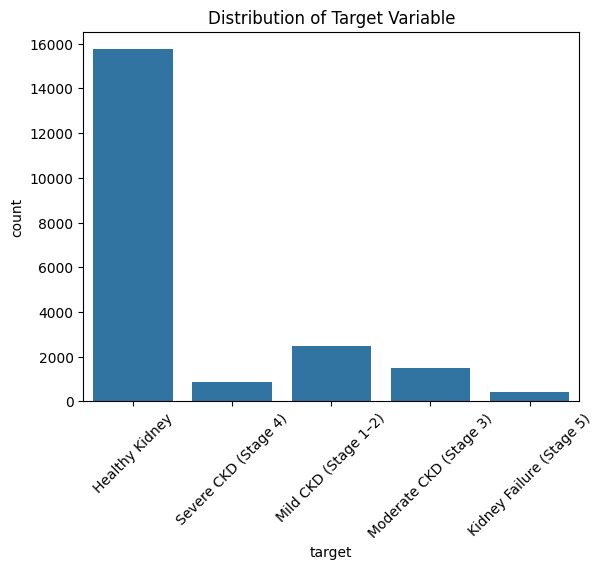

In [5]:
sns.countplot(x='target', data=train_df)
plt.title('Distribution of Target Variable')
plt.xticks(rotation=45)

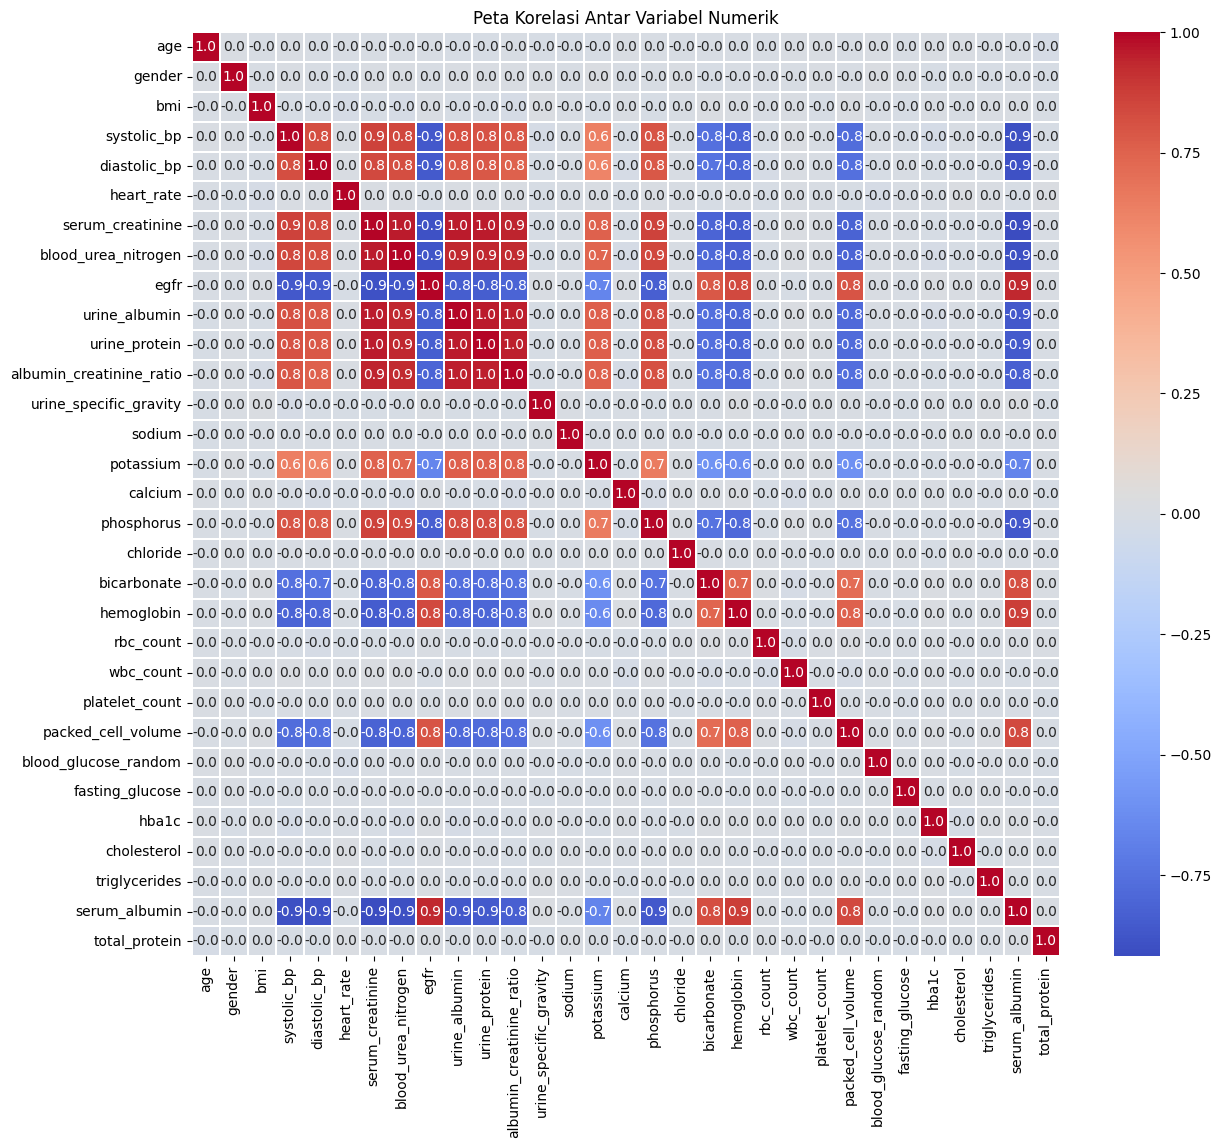

In [6]:
# Heatmap Korelasi (Hanya untuk data numerik)
plt.figure(figsize=(14, 12))
# Memilih hanya kolom dengan tipe data numerik (int/float)
numeric_train_df = train_df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_train_df.corr(), annot=True, cmap='coolwarm', fmt=".1f", linewidths=1.2)
plt.title('Peta Korelasi Antar Variabel Numerik')
plt.show()

In [7]:
# =====================================================================
# 1. PREPROCESSING & LABELING
# =====================================================================
print("1. Melakukan Labeling dan Preprocessing...")

# Data Wrangling sederhana (Lowercase kolom)
train_df.columns = train_df.columns.str.lower().str.replace(' ', '_')
test_df.columns = test_df.columns.str.lower().str.replace(' ', '_')

# 2. Pemisahan Fitur dan Target
X_train_raw = train_df.drop('target', axis=1)
y_train = train_df['target']
X_test_raw = test_df.drop('target', axis=1)
y_test = test_df['target']

# 3. One-Hot Encoding untuk fitur kategorikal
# Kita gabungkan dulu agar kolom hasil encoding konsisten antara train dan test
X_all = pd.concat([X_train_raw, X_test_raw])
X_all_encoded = pd.get_dummies(X_all, drop_first=True)

X_train = X_all_encoded.iloc[:len(X_train_raw)]
X_test = X_all_encoded.iloc[len(X_train_raw):]

# 4. Label Encoding untuk Target
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Preprocessing selesai. Fitur sekarang bertipe numerik.")

1. Melakukan Labeling dan Preprocessing...
Preprocessing selesai. Fitur sekarang bertipe numerik.


In [8]:
# Pipeline SelectFromModel
select_pipeline = ImbPipeline([
    ('scaler', MinMaxScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        threshold="median"
    ))
])

select_pipeline.fit(X_train, y_train_encoded)
selected_features = X_train.columns[select_pipeline.named_steps['feature_selection'].get_support()]

In [9]:
# 1. Ambil model RF yang ada di dalam feature_selection
selector = select_pipeline.named_steps['feature_selection']
importances = selector.estimator_.feature_importances_

# 2. Buat DataFrame untuk membandingkan fitur dan skornya
df_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# 3. Urutkan dari yang tertinggi
df_importance = df_importance.sort_values(by='Importance', ascending=False)

# 4. Tampilkan fitur yang statusnya terpilih (True)
df_importance['Selected'] = selector.get_support()
print(df_importance[df_importance['Selected'] == True])

                     Feature  Importance  Selected
3                systolic_bp    0.100717      True
7        blood_urea_nitrogen    0.099358      True
9              urine_albumin    0.087268      True
11  albumin_creatinine_ratio    0.085663      True
10             urine_protein    0.084327      True
4               diastolic_bp    0.079848      True
19                hemoglobin    0.046832      True
16                phosphorus    0.031864      True
18               bicarbonate    0.031396      True
23        packed_cell_volume    0.018920      True
13                    sodium    0.000424      True
15                   calcium    0.000241      True
17                  chloride    0.000218      True
2                        bmi    0.000065      True
21                 wbc_count    0.000035      True
5                 heart_rate    0.000032      True
24      blood_glucose_random    0.000019      True
12    urine_specific_gravity    0.000000      True


/tmp/ipykernel_2984/2681981575.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=selected_importance, palette='viridis')


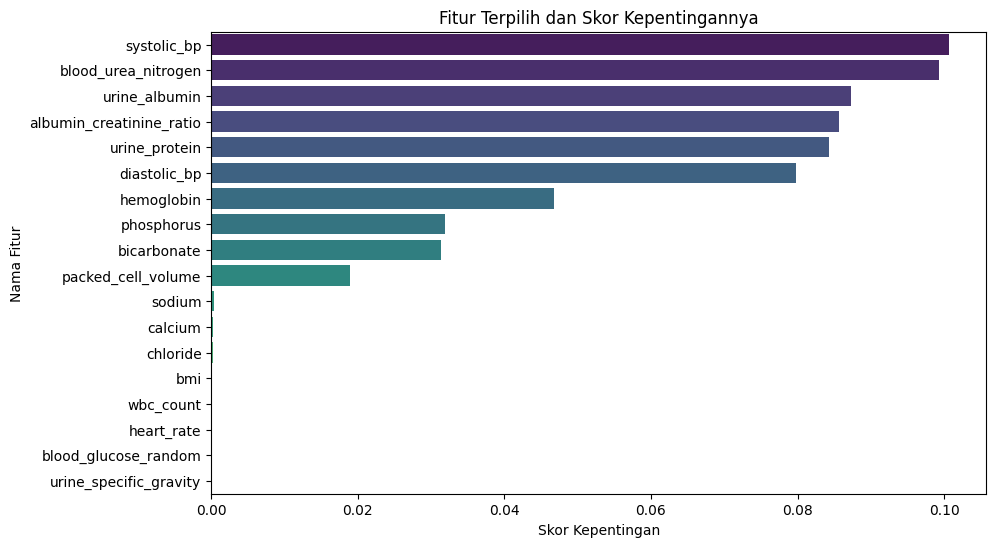

In [10]:
# Ambil hanya fitur yang terpilih untuk diplot
selected_importance = df_importance[df_importance['Selected'] == True]

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=selected_importance, palette='viridis')
plt.title('Fitur Terpilih dan Skor Kepentingannya')
plt.xlabel('Skor Kepentingan')
plt.ylabel('Nama Fitur')
plt.show()

In [11]:
param_space = {
'classifier__n_estimators': (100, 500),
'classifier__max_depth': (5, 50),
'classifier__min_samples_split': (2, 10),
'classifier__min_samples_leaf': (1, 5),
'classifier__max_features': ['sqrt', 'log2']
}

# Filter data hanya fitur yang terpilih
X_train_selected = X_train[selected_features]

# Pipeline baru tanpa RFECV (lebih ringan)
final_pipeline = ImbPipeline([
    ('scaler', MinMaxScaler()),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Jalankan BayesSearchCV hanya untuk tuning model
opt = BayesSearchCV(
    estimator=final_pipeline,
    search_spaces=param_space,
    n_iter=10,
    cv=StratifiedKFold(3),
    n_jobs=-1,
    random_state=42
)
opt.fit(X_train_selected, y_train_encoded)

BayesSearchCV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=False),
              estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                        ('smoteenn', SMOTEENN(random_state=42)),
                                        ('classifier',
                                         RandomForestClassifier(random_state=42))]),
              n_iter=10, n_jobs=-1, random_state=42,
              search_spaces={'classifier__max_depth': (5, 50),
                             'classifier__max_features': ['sqrt', 'log2'],
                             'classifier__min_samples_leaf': (1, 5),
                             'classifier__min_samples_split': (2, 10),
                             'classifier__n_estimators': (100, 500)})

In [14]:
# 7. Evaluasi
print(f"Best Score: {opt.best_score_}")

# Filter X_test agar hanya berisi fitur yang digunakan saat fit
X_test_selected = X_test[selected_features]

y_pred = opt.predict(X_test_selected)

Best Score: 1.0


In [15]:
print("Evaluasi Model pada Data Test...")
print("Accuracy Test:", accuracy_score(y_test_encoded, y_pred))
print("Precision Test:", precision_score(y_test_encoded, y_pred, average='weighted'))
print("Recall Test:", recall_score(y_test_encoded, y_pred, average='weighted'))
print("F1 Score Test:", f1_score(y_test_encoded, y_pred, average='weighted'))

Evaluasi Model pada Data Test...
Accuracy Test: 1.0
Precision Test: 1.0
Recall Test: 1.0
F1 Score Test: 1.0


In [16]:
print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))


Classification Report:

                          precision    recall  f1-score   support

          Healthy Kidney       1.00      1.00      1.00      3615
Kidney Failure (Stage 5)       1.00      1.00      1.00        96
    Mild CKD (Stage 1–2)       1.00      1.00      1.00       575
  Moderate CKD (Stage 3)       1.00      1.00      1.00       318
    Severe CKD (Stage 4)       1.00      1.00      1.00       196

                accuracy                           1.00      4800
               macro avg       1.00      1.00      1.00      4800
            weighted avg       1.00      1.00      1.00      4800



Visualisasi Confusion Matrix


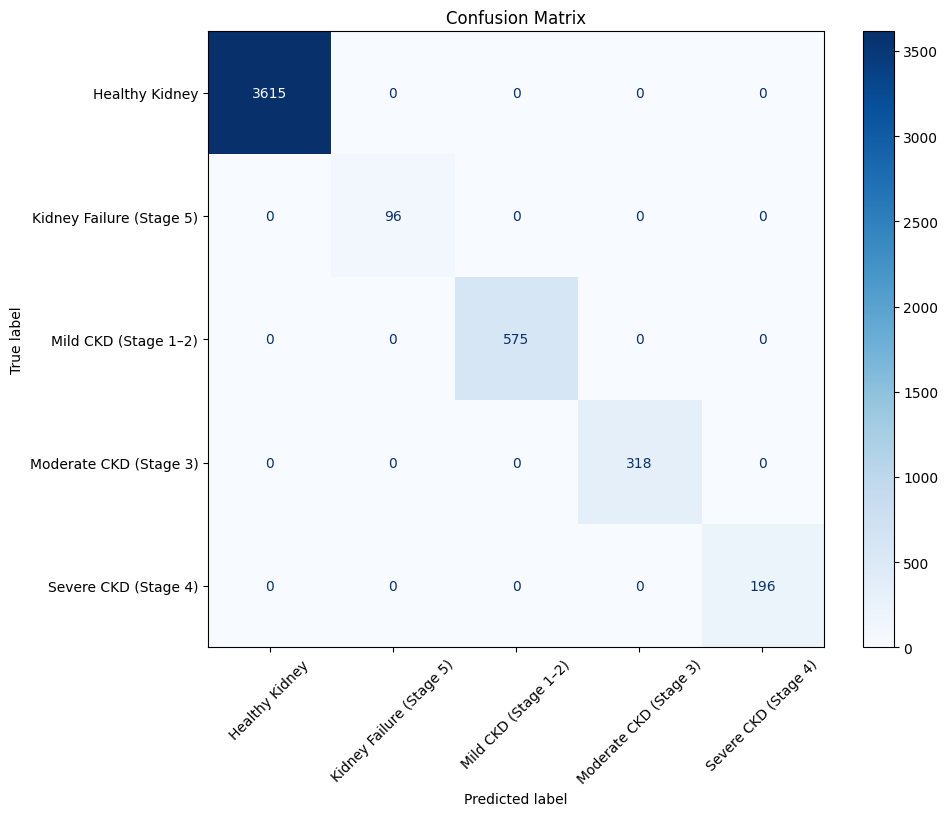

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

print("Visualisasi Confusion Matrix")

# Hitung matrix
cm = confusion_matrix(y_test_encoded, y_pred)

# Visualisasikan dengan label yang benar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [19]:
# 1. Save the best model and objects needed for prediction
# Menyimpan model terbaik dari hasil Bayesian Optimization
best_model = opt.best_estimator_
joblib.dump(best_model, 'ckd_pipeline_model.pkl')

# Menyimpan label encoder agar dashboard tahu arti angka 0, 1, 2, dst.
joblib.dump(le, 'label_encoder.pkl')

print("Model dan Encoder berhasil disimpan!")

Model dan Encoder berhasil disimpan!


In [23]:
# Menyimpan daftar nama fitur agar aplikasi Streamlit konsisten
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')

print(f"Berhasil menyimpan {len(feature_names)} nama fitur ke feature_names.pkl")

Berhasil menyimpan 35 nama fitur ke feature_names.pkl
